# <p style="text-align:center">**Laptops Pricing Model Development**

# Objectives


 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

In [2]:
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [3]:
df = pd.read_csv(path)
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [4]:
df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)
df

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,Lenovo,4,2,1,7,14.0,0.896552,8,256,3.74850,1891,Medium,0,1
234,Toshiba,3,2,1,5,13.3,0.827586,8,256,2.64600,1950,Medium,1,0
235,Lenovo,4,2,1,5,12.0,0.896552,8,256,2.99880,2236,Medium,0,1
236,Lenovo,3,3,1,5,15.6,0.862069,6,256,5.29200,883,Low,1,0


## Single Linear Regression

From the previous lab, "RAM_GB" is the parameter with the lowest p-value among the different features of the dataset. Creating a single feature Linear Regression model that fits the pair of "RAM_GB" and "Price" to find the model for prediction.


In [5]:
lm = LinearRegression()

X = df[['RAM_GB']]
Y = df['Price']

lm.fit(X,Y)

Yhat=lm.predict(X)

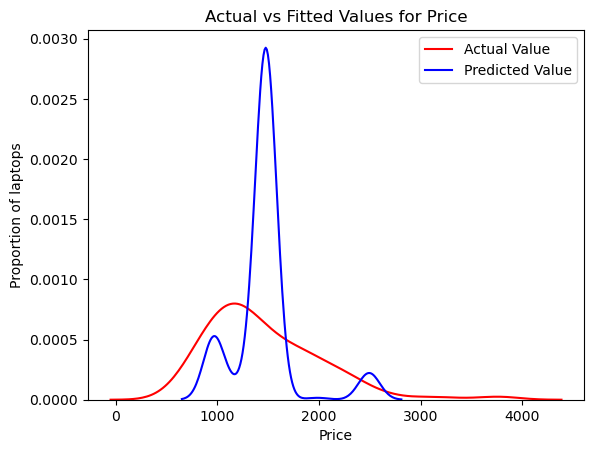

In [6]:
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")

# Creating a distribution plot for predicted values
sns.distplot(Yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()

## Evaluation of the Mean Squared Error and R^2 score values for the model. 
When evaluating a model, a quantitative measure is required to determine how accurate the model is.

Two very important measures that are often used in Statistics to determine the accuracy of a model are:

+ **R^2 / R-squared**
+ **Mean Squared Error (MSE)**

**R-squared**

R squared, also known as the coefficient of determination, is a measure to indicate how close the data is to the fitted regression line.

The value of the R-squared is the percentage of variation of the response variable (y) that is explained by a linear model.

**Mean Squared Error (MSE)**

The Mean Squared Error measures the average of the squares of errors. That is, the difference between actual value (y) and the estimated value (ŷ).

In [7]:
mse_slr = mean_squared_error(df['Price'], Yhat)
r2_score_slr = lm.score(X, Y)
print('The R-square for Linear Regression is: ', r2_score_slr)
print('The mean square error of price and predicted value is: ', mse_slr)

The R-square for Linear Regression is:  0.3017275206956078
The mean square error of price and predicted value is:  229582.71927482335


# Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'RAM_GB', 'CPU_core', 'CPU_frequency', 'GPU', 'Category', 'OS' and  'Storage_GB_SSD'. Use all these variables to create a Multiple Linear Regression system. 


In [8]:
lm1 = LinearRegression()
Z = df[['RAM_GB','CPU_core','CPU_frequency','GPU','Category','OS','Storage_GB_SSD']]
lm1.fit(Z,Y)
Y_hat = lm1.predict(Z)

Plotting the Distribution graph of the predicted valuePs as well as the Actual values

Text(0, 0.5, 'Proportion of laptops')

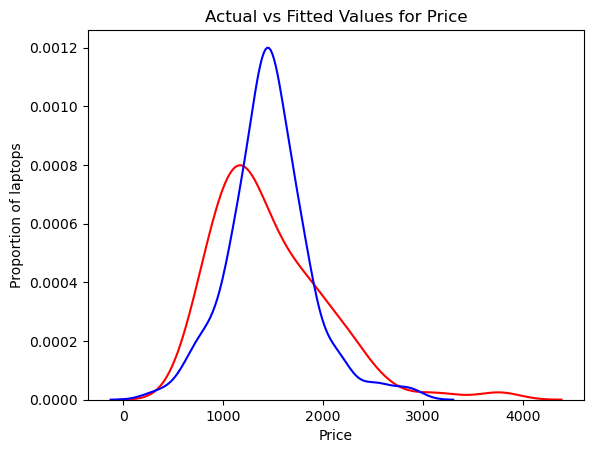

In [9]:
ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')

Finding the R^2 score and the MSE value for this fit.

In [10]:
mse_mlr = mean_squared_error(df['Price'], Y_hat)
r2_score_mlr = lm1.score(Z, Y)
print('The R-square for Multiple Linear Regression is: ', r2_score_mlr)
print('The mean square error of price and predicted value is: ', mse_mlr)

The R-square for Multiple Linear Regression is:  0.5082509055187374
The mean square error of price and predicted value is:  161680.57263893107


# Polynomial Regression
Using the variable "RAM_GB" to create Polynomial features for 3 different values of polynomial degrees. 

In [11]:
X = X.to_numpy().flatten()
f1 = np.polyfit(X, Y, 1)
p1 = np.poly1d(f1)

f3 = np.polyfit(X, Y, 3)
p3 = np.poly1d(f3)

f5 = np.polyfit(X, Y, 5)
p5 = np.poly1d(f5)

Plotting the regression output against the actual data points to note how the data fits in each case.

In [12]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

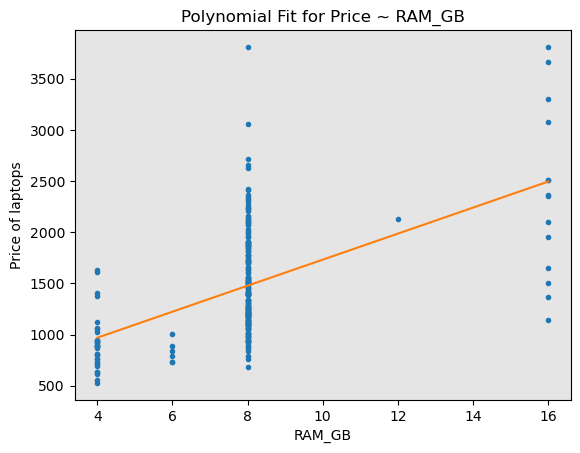

In [13]:
# Call for function of degree 1
PlotPolly(p1, X, Y, 'RAM_GB')

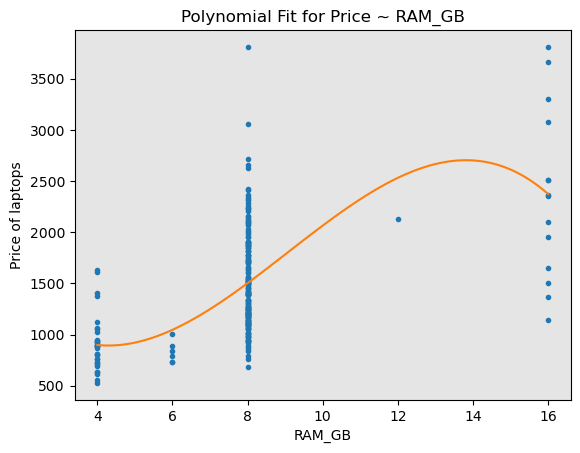

In [14]:
# Call for function of degree 3
PlotPolly(p3, X, Y, 'RAM_GB')

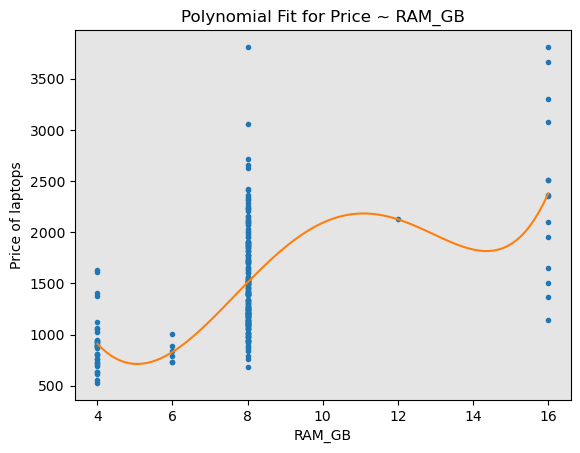

In [15]:
# Call for function of degree 5
PlotPolly(p5, X, Y, 'RAM_GB')

Calculating the R^2 and MSE values for these fits.

In [16]:
r_squared_1 = r2_score(Y, p1(X))
print('The R-square value for 1st degree polynomial is: ', r_squared_1)
print('The MSE value for 1st degree polynomial is: ', mean_squared_error(Y,p1(X)))
r_squared_3 = r2_score(Y, p3(X))
print('The R-square value for 3rd degree polynomial is: ', r_squared_3)
print('The MSE value for 3rd degree polynomial is: ', mean_squared_error(Y,p3(X)))
r_squared_5 = r2_score(Y, p5(X))
print('The R-square value for 5th degree polynomial is: ', r_squared_5)
print('The MSE value for 5th degree polynomial is: ', mean_squared_error(Y,p5(X)))

The R-square value for 1st degree polynomial is:  0.3017275206956078
The MSE value for 1st degree polynomial is:  229582.71927482335
The R-square value for 3rd degree polynomial is:  0.31421153116195555
The MSE value for 3rd degree polynomial is:  225478.1424008004
The R-square value for 5th degree polynomial is:  0.3200938770330719
The MSE value for 5th degree polynomial is:  223544.1051863433


# Pipeline
Creating a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Using the set of multiple features as before to create this pipeline. 


In [17]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

First, the data type Z is converted to type float to avoid conversion warnings that may appear as a result of StandardScaler taking float inputs.

The data is then normalize, a transform is performed and fit the model simultaneously

In [18]:
Z = Z.astype(float)
pipe.fit(Z,Y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [19]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([1511.75,  503.75, 1090.25, 1152.25])

Evaluating the MSE and R^2 values for the this predicted output.

In [20]:
print('MSE for multi-variable polynomial pipeline is: ', mean_squared_error(Y, ypipe))
print('R^2 for multi-variable polynomial pipeline is: ', r2_score(Y, ypipe))

MSE for multi-variable polynomial pipeline is:  144214.70614495798
R^2 for multi-variable polynomial pipeline is:  0.5613730827386478


### Conclusion
The values of R^2 increases from Single Linear Regression to Multiple Linear Regression. Further, for multiple linear regression extended with polynomial features, there is a better R^2 value.
